In [3]:
import numpy as np
import pandas as pd
import keras
import cv2
from matplotlib import pyplot as plt
import os
import random
from PIL import Image

In [4]:
import shutil
shutil.copy('/content/drive/MyDrive/train.csv', '/content/train.csv')

'/content/train.csv'

In [5]:
df = pd.read_csv("train.csv")
base_path = "images"

In [6]:
samples = 20000

available = set()
for root, dirs, files in os.walk("images"):
    for f in files:
        if f.endswith(".jpg"):
            available.add(f.replace(".jpg", ""))

df = pd.read_csv("train.csv")[["id", "landmark_id"]]
df = df[df["id"].isin(available)]
df = df.sample(n=min(samples, len(df)), random_state=42)
num_classes = len(df["landmark_id"].unique())
num_data = len(df)
print(f"Using {num_data} samples across {num_classes} classes")

Using 8266 samples across 7444 classes


In [7]:
num_classes

7444

In [8]:
num_data

8266

In [9]:
data = pd.DataFrame(df["landmark_id"].value_counts())

data.reset_index(inplace=True)

data.columns=['index', 'landmark_id']

data['landmark_id'].describe()

,landmark_id
count,7444.000000
mean,1.110425
std,0.502744
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,25.000000


In [10]:
data.head()

,index,landmark_id
0,138982,25
1,62798,11
2,171772,8
3,83144,8
4,45428,7


In [11]:
data.tail()

,index,landmark_id
7439,128629,1
7440,120518,1
7441,102523,1
7442,58578,1
7443,199450,1


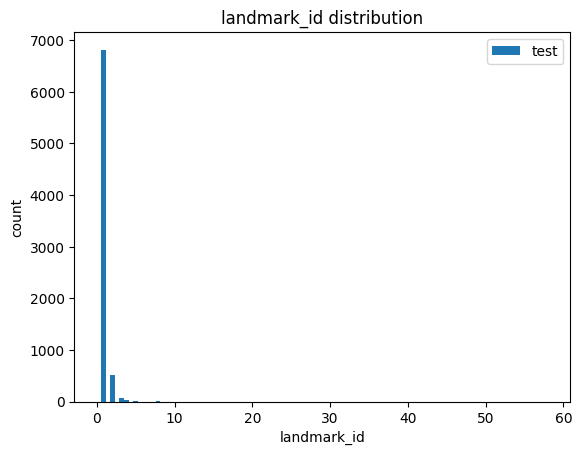

In [12]:
plt.hist(data['landmark_id'], 100, range = (0,58), label = 'test')
plt.xlabel('landmark_id')
plt.ylabel('count')
plt.title('landmark_id distribution')
plt.legend()
plt.show()

In [13]:
data['landmark_id'].between(0,5).sum()

data['landmark_id'].between(5,10).sum()

np.int64(10)

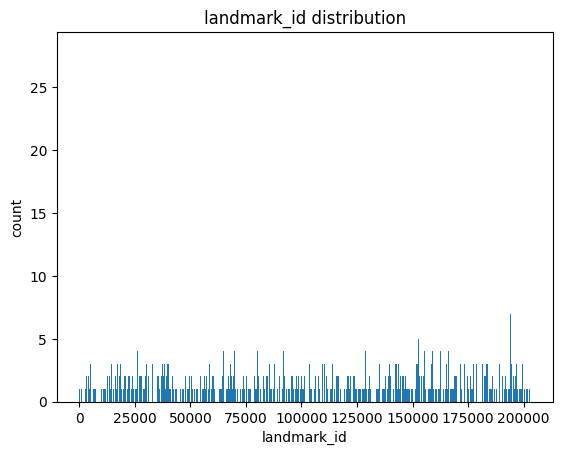

In [14]:
plt.hist(df["landmark_id"], bins=len(df["landmark_id"].unique()))
plt.xlabel('landmark_id')
plt.ylabel('count')
plt.title('landmark_id distribution')
plt.show()


In [15]:
# Training of Model
from sklearn.preprocessing import LabelEncoder
lencoder = LabelEncoder()
lencoder.fit(df["landmark_id"])

LabelEncoder()

In [16]:
def encode_label(lbl):
    return lencoder.transform(lbl)


In [17]:
def decode_label(lbl):
 return lencoder.inverse_transform(lbl)

In [18]:
def get_image_from_number(num, df):
    row = df[num]          # df is numpy array with 2 cols: [id, landmark_id]
    fname = str(row[0])
    label = row[1]
    f1 = fname[0]
    f2 = fname[1]
    f3 = fname[2]
    path = os.path.join(f1, f2, f3, fname + '.jpg')
    full_path = os.path.join(base_path, path)
    im = cv2.imread(full_path)
    if im is None:
        print(f"Image not found: {full_path}")
    return im, label

4 Sample images from random classes


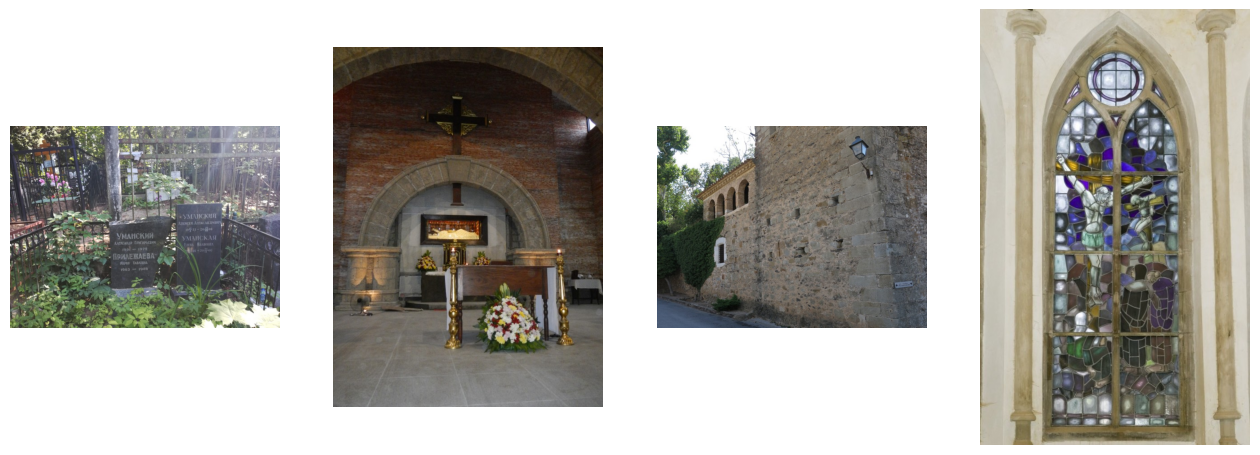

In [19]:
print("4 Sample images from random classes")
fig = plt.figure(figsize=(16,16))
for i in range(1,5):
 ri = random.choices(os.listdir(base_path), k=3)
 folder = base_path + '/' + ri[0] + '/' + ri[1] + '/' + ri[2]
 random_img = random.choice(os.listdir(folder))
 img = np.array(Image.open(folder+'/'+random_img))
 fig.add_subplot(1,4,i)
 plt.imshow(img)
 plt.axis('off')
plt.show()

In [20]:
from keras.applications.vgg19 import VGG19
from keras.layers import *
from keras import Sequential
import tensorflow as tf



In [21]:
# Parameters
learning_rate = 0.0001
decay_speed   = 1e-6
momentum = 0.09
loss_function = "sparse_categorical_crossentropy"
source_model = VGG19(weights=None)
drop_layer = Dropout(0.5)
drop_layer2 = Dropout(0.5)



In [22]:
model = Sequential()
for layer in source_model.layers[ :- 1]:
    if layer == source_model.layers[-25]:
     model.add(BatchNormalization())
    model.add(layer)
model.add(Dense(num_classes, activation = "softmax"))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 224, 224, 3)    │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 170,068,320 (648.76 MB)

 Trainable params: 170,068,314 (648.76 MB)

 Non-trainable params: 6 (24.00 B)

In [23]:
optim1 = keras.optimizers.RMSprop(learning_rate=learning_rate)
model.compile(optimizer=optim1,
               loss=loss_function,
                   metrics = ["accuracy"])

In [24]:
def image_reshape(im, target_size):
    return cv2.resize(im, target_size)

In [25]:
def get_batch(dataframe, start, batch_size):
    image_array = []
    label_array = []

    end_img = min(start + batch_size, len(dataframe))

    for idx in range(start, end_img):
        row = dataframe[idx]
        fname = str(row[0])
        label = row[1]
        f1 = fname[0]
        f2 = fname[1]
        f3 = fname[2]
        path = os.path.join(f1, f2, f3, fname + '.jpg')
        full_path = os.path.join(base_path, path)
        im = cv2.imread(full_path)
        if im is None:
            continue
        im = image_reshape(im, (224, 224)) / 255.0
        image_array.append(im)
        label_array.append(label)

    if len(label_array) == 0:
        return np.array([]), np.array([])

    label_array = encode_label(label_array)
    return np.array(image_array), np.array(label_array)

In [26]:
batch_size = 16
epoch_shuffle = True
weight_classes = True
epochs = 1


df_array = df.to_numpy()
np.random.shuffle(df_array)
split = int(0.8 * len(df_array))
train = df_array[:split]
val = df_array[split:]
print(len(train))
print(len(val))


6612
1654


In [27]:
total_batches = int(np.ceil(len(train) / batch_size))

for e in range(epochs):
    print("Epoch: " + str(e + 1) + "/" + str(epochs))
    if epoch_shuffle:
        train = train[np.random.permutation(len(train))]
    for it in range(total_batches):
        X_train, y_train = get_batch(train, it * batch_size, batch_size)
        if len(X_train) == 0:
            continue
        model.train_on_batch(X_train, y_train)
        if it % 50 == 0:  # prints progress every 50 batches
            print(f"  Batch {it}/{total_batches}")

model.save("Model.keras")
print("Done!")

Epoch: 1/1
  Batch 0/414
  Batch 50/414
  Batch 100/414
  Batch 150/414
  Batch 200/414
  Batch 250/414
  Batch 300/414
  Batch 350/414
  Batch 400/414
Done!


1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

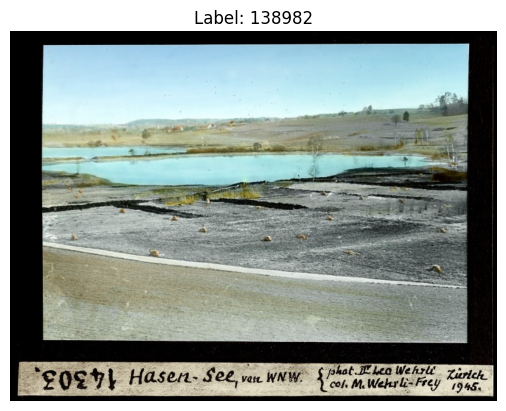

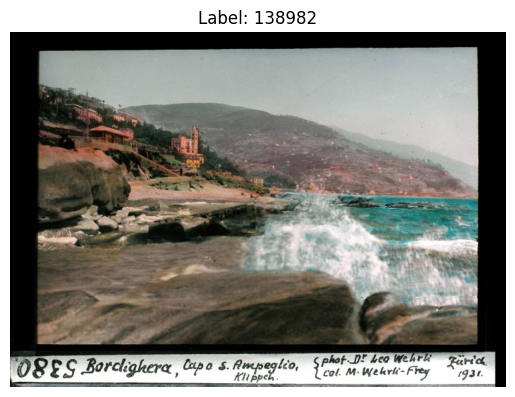

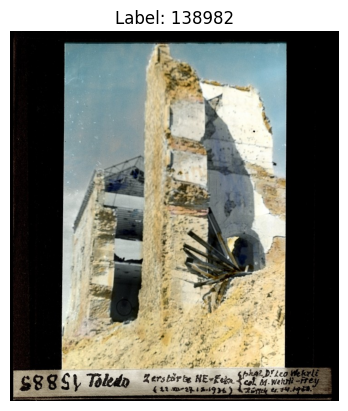

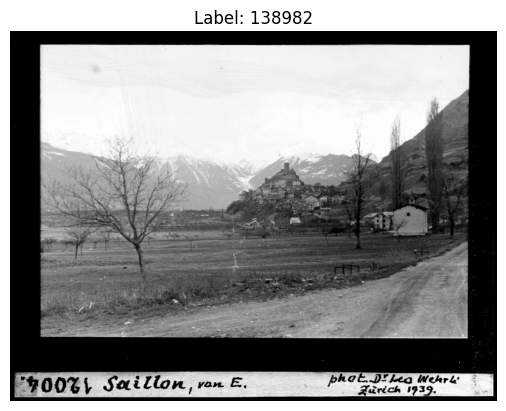

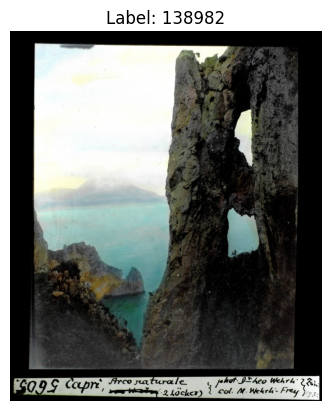

In [28]:
batch_size = 16

errors = 0
good_preds = []
bad_preds = []

for it in range(int(np.ceil(len(val) / batch_size))):
    X_val, y_val = get_batch(val, it * batch_size, batch_size)
    if len(X_val) == 0:
        continue

    result = model.predict(X_val)
    cla = np.argmax(result, axis=1)
    for idx, res in enumerate(result):
        if cla[idx] != y_val[idx]:
            errors += 1
            bad_preds.append([batch_size * it + idx, cla[idx], res[cla[idx]]])
        else:
            good_preds.append([batch_size * it + idx, cla[idx], res[cla[idx]]])

good_preds = np.array(good_preds)

if len(good_preds) == 0:
    print("No correct predictions to display.")
else:
    good_preds = good_preds.reshape(-1, 3)
    num_to_show = min(5, len(good_preds))
    for i in range(num_to_show):
        n = int(good_preds[i, 0])
        img, lbl = get_image_from_number(n, val)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.imshow(img)
            plt.title(f'Label: {lbl}')
            plt.axis('off')
            plt.show()